In [112]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [113]:
df_user_data = pd.read_csv('dataframes/user_data.csv', sep=',')
df_logs = pd.read_csv('dataframes/logs.csv', sep=',')

In [114]:
df_user_data.head()

,client,premium,age
0,46346,False,58
1,4391,False,55
2,27372,False,64
3,11989,False,44
4,60664,False,49


In [115]:
df_logs.head()

,client,success,platform,time
0,40177,True,phone,1585412212
1,61468,True,phone,1585425658
2,35604,False,phone,1585459894
3,9961,True,phone,1585400189
4,10931,True,computer,1585468629


In [116]:
success_number = df_logs.query("success==True").groupby(['client'], as_index=False).agg({'platform':'count'}).rename(columns={'platform':'success_number'}).sort_values('success_number', ascending=False)
maximum_success = success_number.success_number.max()
print(*success_number.query("success_number==@maximum_success").client.sort_values().to_list(), sep=', ')

12179, 28719, 36165, 52870, 61468, 61473, 78349, 82563, 92584


In [117]:
df_logs.loc[df_logs.success == True].platform.value_counts().idxmax()

'phone'

In [118]:
df_logs.merge(df_user_data).query("premium==True").platform.value_counts().idxmax()


'phone'

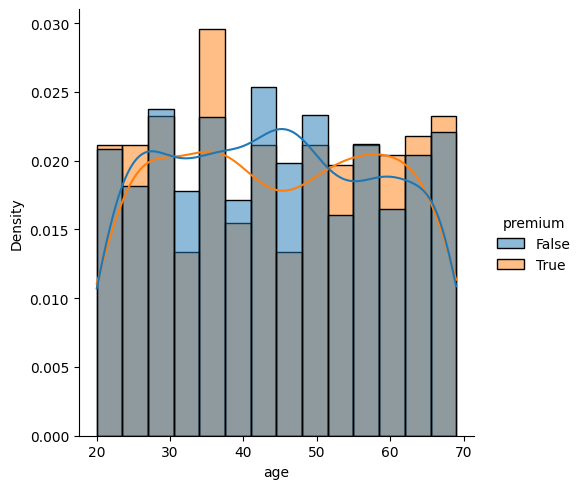

In [123]:
sns.displot(data=df_user_data, x='age', hue='premium', kde=True, kind='hist', 
            stat='density', common_norm=False, bins=14)

/var/folders/9p/2b9k_p8n1_xcx6qqb22xgw780000gn/T/ipykernel_83807/3150419681.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df, kde=False)


<Axes: >

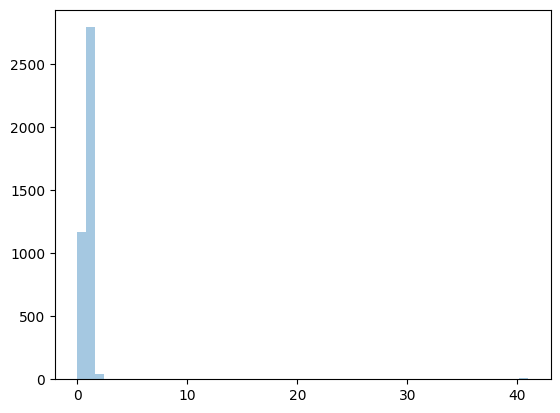

In [136]:
df = df_logs.groupby('client').agg({'success':'sum'})
sns.distplot(df, kde=False)

In [137]:
df.value_counts()

success
1          2791
0          1166
2            43
41            9
3             1
40            1
Name: count, dtype: int64

<Axes: xlabel='age', ylabel='success'>

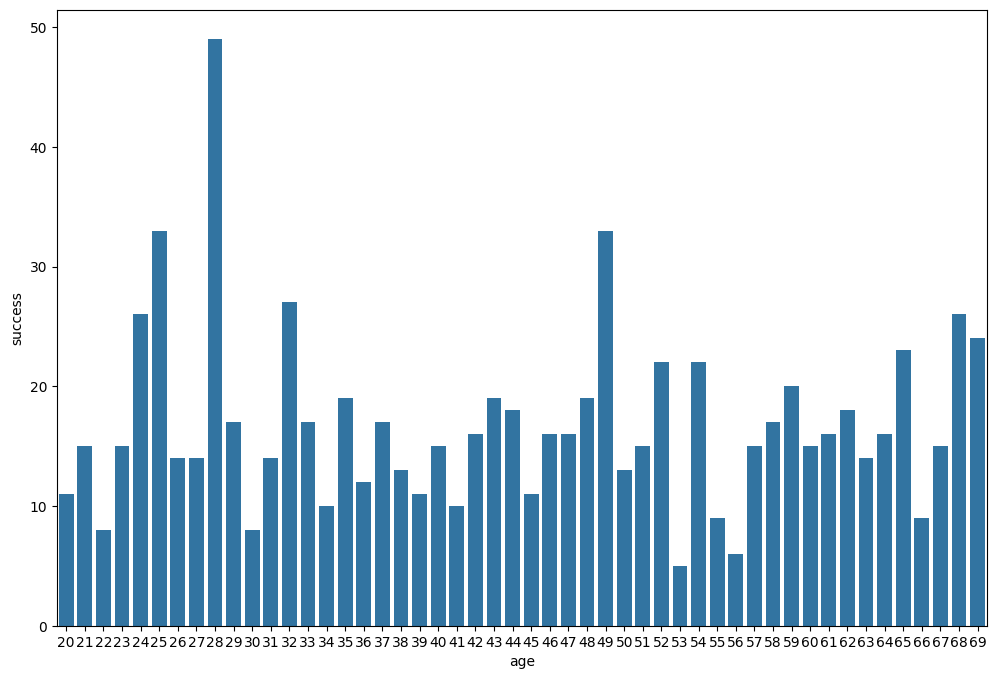

In [162]:
df = df_logs.merge(df_user_data).query("success==True and platform == 'computer'").groupby('age', as_index=False).agg({'success':'sum'})
plt.figure(figsize=(12, 8))
sns.barplot(x='age', y='success', data=df)

<Axes: ylabel='count'>

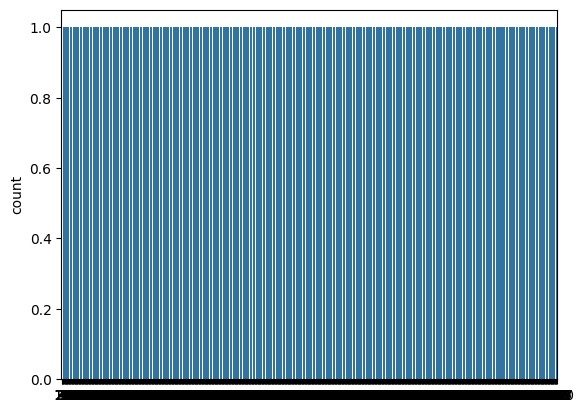

In [166]:
data = df_user_data.merge(df_logs)
data.head()
computer_success = data.query("platform=='computer' and success==True")
sns.countplot(computer_success.age)